In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [15]:
df = pd.read_csv('StudentPerformanceFactors.csv')

# df.columns

print("Shape:", df.shape)
print("\nColumns and Types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

cols = [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in cols:
    df[col] = df[col].fillna('Unknown')

print("\nMissing values-after-fill:\n", df.isnull().sum())

Shape: (6607, 20)

Columns and Types:
 Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Missing values:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours             

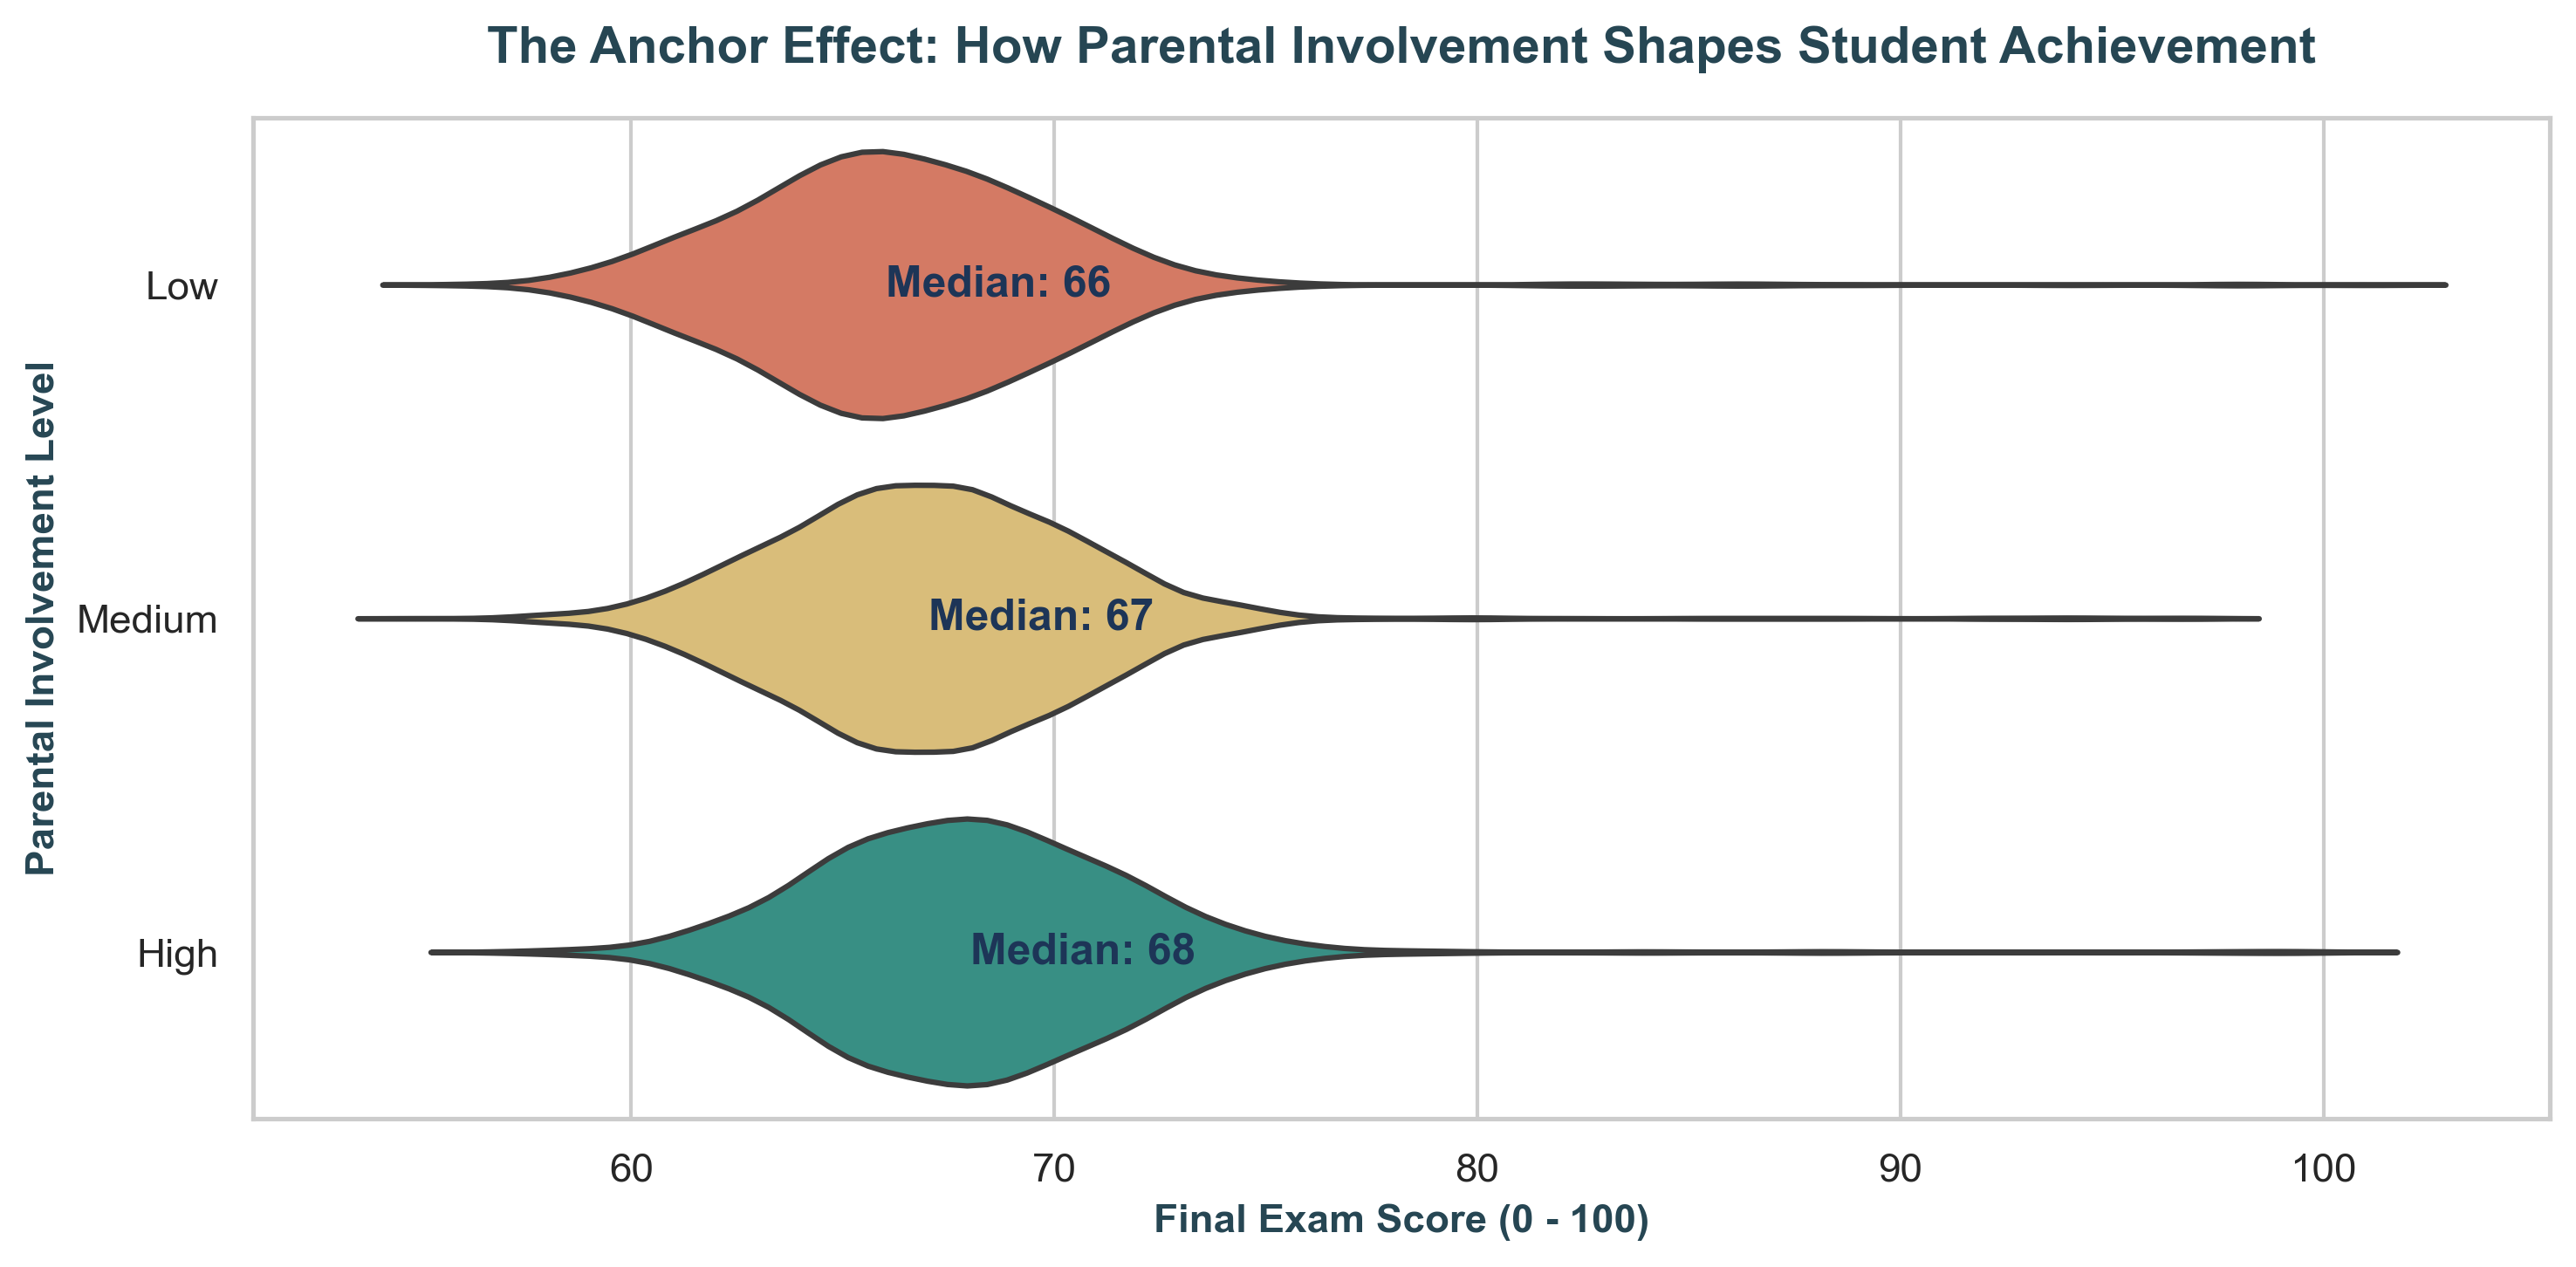

In [29]:
sns.set_theme(style="whitegrid", font="sans-serif")

plt.figure(figsize=(10, 5), dpi=300)

palette = {"Low": "#E76F51", "Medium": "#E9C46A", "High": "#2A9D8F"}

ax = sns.violinplot(
    data=df,
    y="Parental_Involvement",
    x="Exam_Score",
    hue="Parental_Involvement",
    order=["Low", "Medium", "High"],
    palette=palette,
    inner=None,
    linewidth=1.5,
    orient="h",
    legend=False
)

plt.title("The Anchor Effect: How Parental Involvement Shapes Student Achievement", fontsize=14, fontweight='bold', pad=15, color='#264653')
plt.xlabel("Final Exam Score (0 - 100)", fontsize=11, fontweight='bold', color='#264653')
plt.ylabel("Parental Involvement Level", fontsize=11, fontweight='bold', color='#264653')

medians = df.groupby('Parental_Involvement')['Exam_Score'].median().reindex(["Low", "Medium", "High"])

for idx, (level, median) in enumerate(medians.items()):
    ax.text(median + 0.025, idx, f"Median: {median:.0f}", color='#1D3557', fontweight='bold', va='center')

plt.tight_layout()
plt.show()